# Data Preparation
**Course:** Management and Analysis of Physics Datasets (MAPD - Part B)  
**Author:** Pasquale Andreacchio (Group 5)  
**Dataset:** Industrial Refrigeration Devices (Chillers / Heat Pumps)

---


# Import the libraries and configure a spark session

In [1]:
from pyspark.sql import SparkSession
import os
import pyspark.sql.functions as sf
from pyspark.sql import Window

In [2]:
# Get the access and secret keys to connect to s3
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_SECRET_KEY") 

# Create a spark session including modules to connect to s3
# Added the third line in which I can set manually the memory usage for each worker
spark = SparkSession.builder \
    .master("spark://master:7077")\
    .appName("Anomaly Detection")\
    .config("spark.executor.memory", "2g")\
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1')\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config('spark.hadoop.fs.s3a.aws.credentials.proviAnvoder', 'org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider')\
    .config('spark.hadoop.fs.s3a.access.key', access_key)\
    .config('spark.hadoop.fs.s3a.secret.key', secret_key)\
    .config('spark.hadoop.fs.s3a.endpoint', 'https://cloud-areapd.pd.infn.it:5210')\
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl", "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled","false") \
    .config("com.amazonaws.sdk.disableCertChecking","true") \
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/nlavarda/.ivy2.5.2/cache
The jars for the packages stored in: /home/nlavarda/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-07bea3d6-2d7d-42c6-96e6-102e4b4e7d10;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failure

# Task 1: conversion of alarms

First of all, we will convert the "A5" and "A9" variables from their integer representation to their bit string one. This will help identifying the required alarms. \
First, we have to read the data file from the CloudVeneto "bucket", converted into the *Parquet* format by  `df_spark.write.mode("overwrite").parquet("s3a://MAPDB-Group5/data_parquet")`

In [3]:
# Read data from the CloudVeneto "bucket" through s3
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet")
df_spark.show(10)

+-------------+------+------+-----+
|         when|  hwid|metric|value|
+-------------+------+------+-----+
|1604265597702|SW-115|   S80|    0|
|1604265597702|SW-115|   S73|    0|
|1604265597702|SW-115|   S72|  100|
|1604265597702|SW-115|   S71|  100|
|1604265597702|SW-115|   P16|  200|
|1604265597702|SW-115|   P15|    0|
|1604265597702|SW-115|   P10|  430|
|1604265597702|SW-115|    P9|  300|
|1604265597702|SW-115|    P8|  150|
|1604265597702|SW-115|    P7|  260|
+-------------+------+------+-----+
only showing top 10 rows


After reading the data, we can convert the `A5` and `A9` metrics to their bitwise representation

In [4]:
# Converting the A5 and A9 metrics to their bit-string representation
# Note: all the other values are converted into strings because Spark
# wants the same type returned by when/otherwise 
df_spark = df_spark.withColumn(
    "BitString",
    sf.when(
        df_spark.metric.isin('A5', 'A9'),
        sf.lpad(sf.bin(df_spark.value), 16, '0')
    ).otherwise(df_spark.value.cast('string'))
)

Now that we have converted the `A5` and `A9` variables to their bit-string representation, we can identify the requested alarms by checking if 1+ bit(s) in position 6, 7 and 8 (staring from the LSB), are 1 in either or both of them, which means that engines are overheating.

In [5]:
# Starting from the LSB, positions 6, 7 and 8 correspond to position 9, 10 and 11
# because the substring function operates from left to right (so from the MSB)
df_spark = df_spark.withColumn(
    "is_overheated",
    sf.when(
        df_spark.metric.isin('A5', 'A9') & 
        (sf.substring(df_spark.BitString, 9, 3) != '000'),
        True
    ).otherwise(False)
)

After identifying all the requested alarms and flagging them with `is_overheated`, we can resample all the metrics to the same sampling frequency, in order to correctly conduct the analysis. \
We chose the sampling frequence to be **1 minute**

In [6]:
# Overwrite the "when" column, representing a UNIX timestamp, casting that to the native "TimestampType"
# using the native spark function
df_spark = df_spark.withColumn(
    "when",
    sf.timestamp_millis(df_spark.when)
)

# Now let's add a "timestamp_bucket" column, "truncating" everything to the minutes
# to get the same sampling frequency for all data
df_spark = df_spark.withColumn(
    "timestamp_bucket",
    sf.date_trunc("minute", "when")
)

# Use flag "truncate=False" to show the whole timestamp
df_spark.show(10, truncate=False)

+-----------------------+------+------+-----+---------+-------------+-------------------+
|when                   |hwid  |metric|value|BitString|is_overheated|timestamp_bucket   |
+-----------------------+------+------+-----+---------+-------------+-------------------+
|2020-11-01 21:19:57.702|SW-115|S80   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S73   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S72   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S71   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P16   |200  |200      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P15   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P10   |430  |430      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P9    |300  |300      |false        |2020-11-01 21:19:00|
|2020-11-0

Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Engine status metrics (S117, S118, S169, S170):** these metrics indicate the ON/OFF power state of the engines (engine 1, 2, 3, and 4, respectively). To aggregate them within a single bucket, we use the **maximum value** detected by the system. This guarantees that if an engine was active at any point during that interval, the state is recorded as active (`1`).

* **Discrete states, binary flags, and alarms (e.g., operational modes, valve statuses, and the `is_overheated` flag):** we also aggregate these using the **maximum value** (acting as a logical OR). This ensures that any alarm event or state transition occurring within the bucket is preserved rather than smoothed out.

* **Continuous physical measurements (e.g., temperatures, pressures, powers, and capacities such as S41, S100, S102, S109, S125, E1):** we aggregate these using the **mean value** Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Cumulative energy counters (E3, E4, E5, E6):** since these variables represent monotonically increasing cumulative readings, we aggregate them using the **maximum value** to reflect the total accumulated energy at the end of the interval.

In [7]:
# List of all the metrics that should be aggregated using their mean
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

# Define a window partitioned by timestamp_bucket and device (hwid).
# We omit orderBy and framing to allow Spark to compute the partition-level max
# without maintaining strict ordering, keeping memory overhead minimal.
w_device = Window.partitionBy("timestamp_bucket", "hwid")

# Propagate the "is_overheated" flag across all records belonging to the same device 
# and bucket window. If any alarm (e.g., 'A5' or 'A9') flagged overheating, 
# all rows in that bucket/device will receive True.
df_with_flag = df_spark.withColumn(
    "is_overheated_device",
    sf.max(sf.col("is_overheated")).over(w_device)
)

# It's important to also groupBy "hwid" which indicates the specific device.
# We use the "coalesce" function because if the metric isn't in the "continuous_metrics" list
# the first expression will implicitly return "null".
# Coalesce returns the first not null value, so if the metric isn't in that list, it will
# automatically pass to the second value and return the max
df_aggregated = (
    df_with_flag.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          sf.coalesce(
              sf.mean(sf.when(sf.col("metric").isin(continuous_metrics), sf.col("value"))),
              sf.max(sf.col("value"))
          ).alias("aggregated_value"),
          sf.first("is_overheated_device").alias("is_overheated")
      )
)

df_aggregated.show(10)

+-------------------+------+------+----------------+-------------+
|   timestamp_bucket|  hwid|metric|aggregated_value|is_overheated|
+-------------------+------+------+----------------+-------------+
|2020-10-01 00:08:00|SW-088|   S43|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   S42|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   S41|           176.0|        false|
|2020-10-01 00:08:00|SW-088|    P7|           260.0|        false|
|2020-10-01 00:08:00|SW-088|    P8|           150.0|        false|
|2020-10-01 00:08:00|SW-088|    P9|           300.0|        false|
|2020-10-01 00:08:00|SW-088|   P10|           450.0|        false|
|2020-10-01 00:08:00|SW-088|   P15|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   P16|           125.0|        false|
|2020-10-01 00:08:00|SW-088|   P17|           400.0|        false|
+-------------------+------+------+----------------+-------------+
only showing top 10 rows


In [8]:
spark.stop()
print("Spark Session stopped successfully.")

Spark Session stopped successfully.


# Scalability & Benchmark Analysis — Distributed Data Ingestion Pipeline

Benchmarking was done by isolating the four computational kernels of the anomaly-detection
pipeline and evaluating their strong-scaling behaviour on the cluster
across executor allocations of N ∈ {1, 2, 4, 6} cores, with five timed repetitions per
configuration, in order to account for system variability and ensure statistically sound measurements. 
Metrics include
wall-clock time, executor CPU time, JVM GC time, and shuffle I/O volume.
An additional experiment sweeps `spark.sql.shuffle.partitions` ∈ {6, 12, 32, 200}
in Task 4 with N = 6 cores
to characterise the sensitivity of the shuffle-bound aggregation task to partition
cardinality.

> **Measurement protocol.** Data reading and BitString alarm conversion are
> excluded from timing; the Parquet dataset is read once and cached before any
> timed run begins. Each task receives the materialised output of its predecessor
> as input, ensuring that only the target transformation is measured.

## 1. Wall-Clock Time per Task (Strong Scaling)

**Figure 1** presents mean wall-clock time (log scale, the shaded area represents 1σ) for each task
across N ∈ {1, 2, 4, 6} cores. The four tasks span nearly three orders of magnitude
in wall-clock time, reflecting their fundamentally different dependency types.

**Table 1 — Mean Wall-Clock Time (seconds)**

| Task | Category | 1 Core | 2 Cores | 4 Cores | 6 Cores |
|---|---|---|---|---|---|
| Task 1: `is_overheated` flag | Map / Narrow | 1.118 ± 0.082 | 0.707 ± 0.101 | 0.421 ± 0.094 | 0.347 ± 0.036 |
| Task 2: Timestamp + `date_trunc` | Map / Narrow | 8.948 ± 0.341 | 5.985 ± 0.194 | 3.851 ± 0.167 | 2.820 ± 0.110 |
| Task 3: Device flag propagation | Window / Wide | 80.011 ± 0.988 | 53.877 ± 4.310 | 31.092 ± 1.379 | 20.496 ± 1.905 |
| Task 4: Metric aggregation | Shuffle / Wide | 140.858 ± 3.581 | 80.732 ± 1.675 | 48.441 ± 1.021 | 34.159 ± 1.060 |

Tasks 1 and 2 execute in under 9 seconds even at 1 core, confirming that their
purely map-side, shuffle-free nature prevents any inter-executor data movement.
Task 3 (`Window.partitionBy`) introduces a mandatory Hash Shuffle Exchange to
co-locate all rows sharing the same `(timestamp_bucket, hwid)` key pair, driving
single-core latency to 80 s. Task 4's `groupBy`-based two-phase aggregation is the
dominant bottleneck at every core count, peaking at 140.9 s with a single executor.

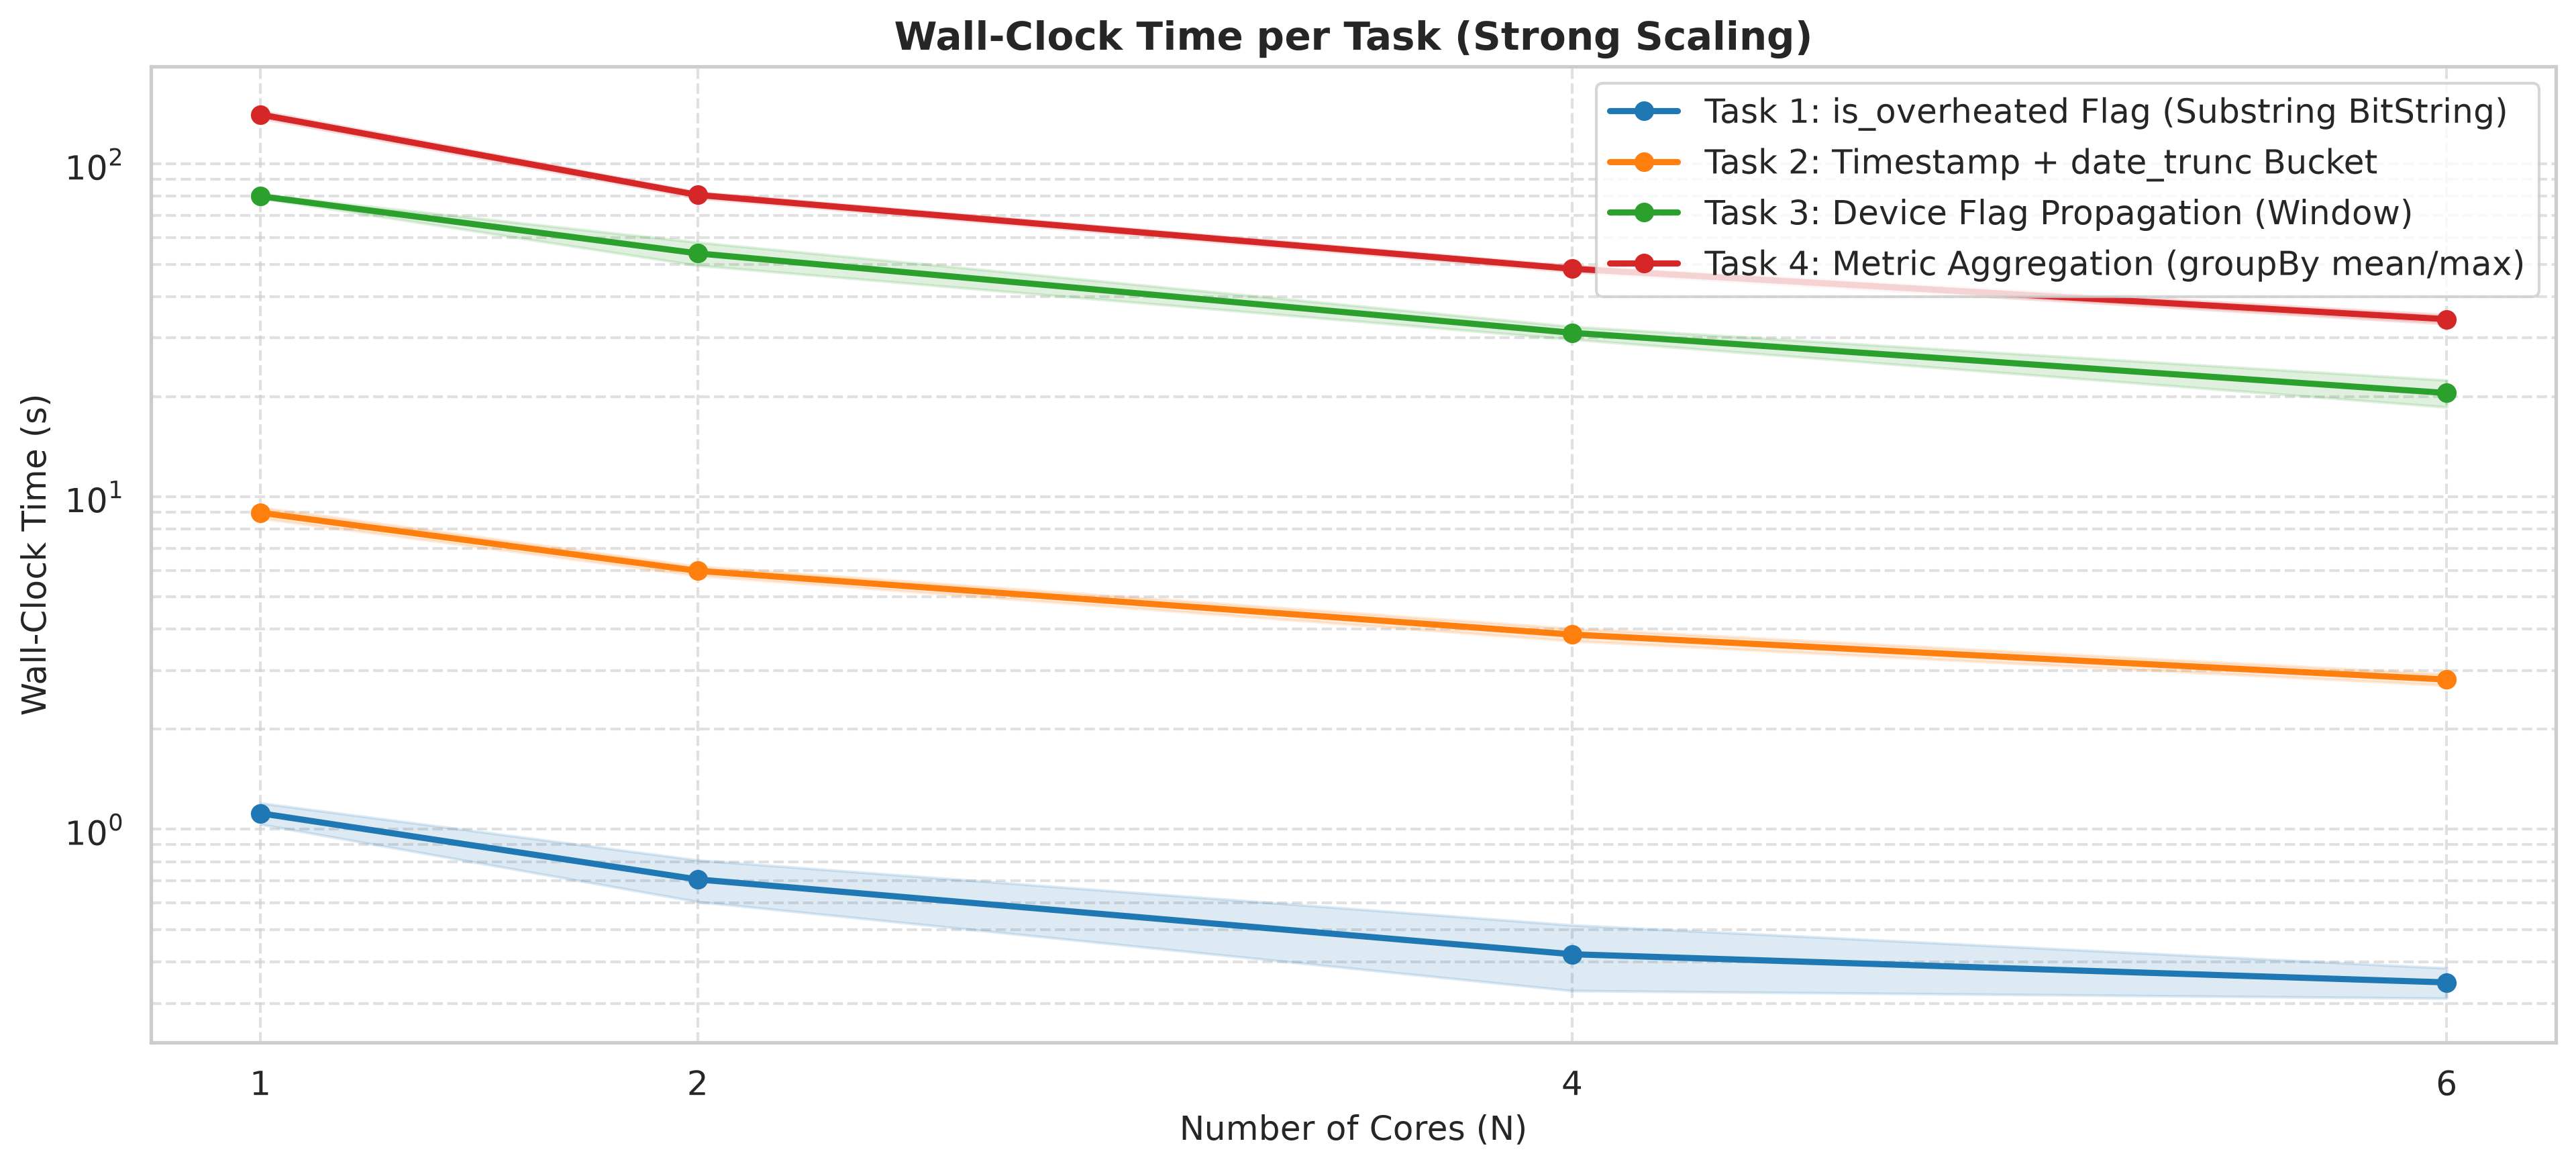

## 2. Strong-Scaling Speedup S(N) = T(1) / T(N)

**Figure 2** shows the empirical speedup curves for all four tasks against the
ideal linear reference S(N) = N. All tasks scale sub-linearly, as predicted by
*Amdahl's Law*, but the degree of deviation is governed by fundamentally different
mechanisms.

**Table 2 — Speedup S(N)**

| Task | S(2) | S(4) | S(6) | Ideal S(6) |
|---|---|---|---|---|
| Task 1: `is_overheated` flag | 1.58× | 2.65× | 3.22× | 6× |
| Task 2: Timestamp + `date_trunc` | 1.50× | 2.32× | 3.17× | 6× |
| Task 3: Device flag propagation | 1.49× | 2.57× | 3.90× | 6× |
| Task 4: Metric aggregation | **1.74×** | **2.91×** | **4.12×** | 6× |

**Narrow tasks (Tasks 1–2).** For workloads such as Task 1, a substantial
fraction of total elapsed time is consumed by fixed, non-parallelisable overhead —
driver-side task serialisation, JVM warm-up, and RPC scheduling latency. As N
increases, the parallelisable fraction shrinks relative to this irreducible cost,
depressing S(6) to 3.22×. Task 2, whose single-core time is ~9 s, exhibits a
similar ceiling (S(6) = 3.17×) because `timestamp_millis` + `date_trunc` are
CPU-intensive string primitives that cannot pipeline across executor boundaries.

**Wide dependency tasks (Tasks 3–4).** The window and aggregation tasks achieve
higher speedups (S(6) = 3.90× and 4.12×, respectively) because their workloads
are sufficiently compute- and I/O-intensive that the fixed overhead is negligible
relative to the parallelisable component. Task 4 consistently leads in speedup at
every N, benefiting from two-phase partial aggregation: each executor independently
reduces its local partition before the final shuffle-reduce phase, effectively
amortising the communication cost.

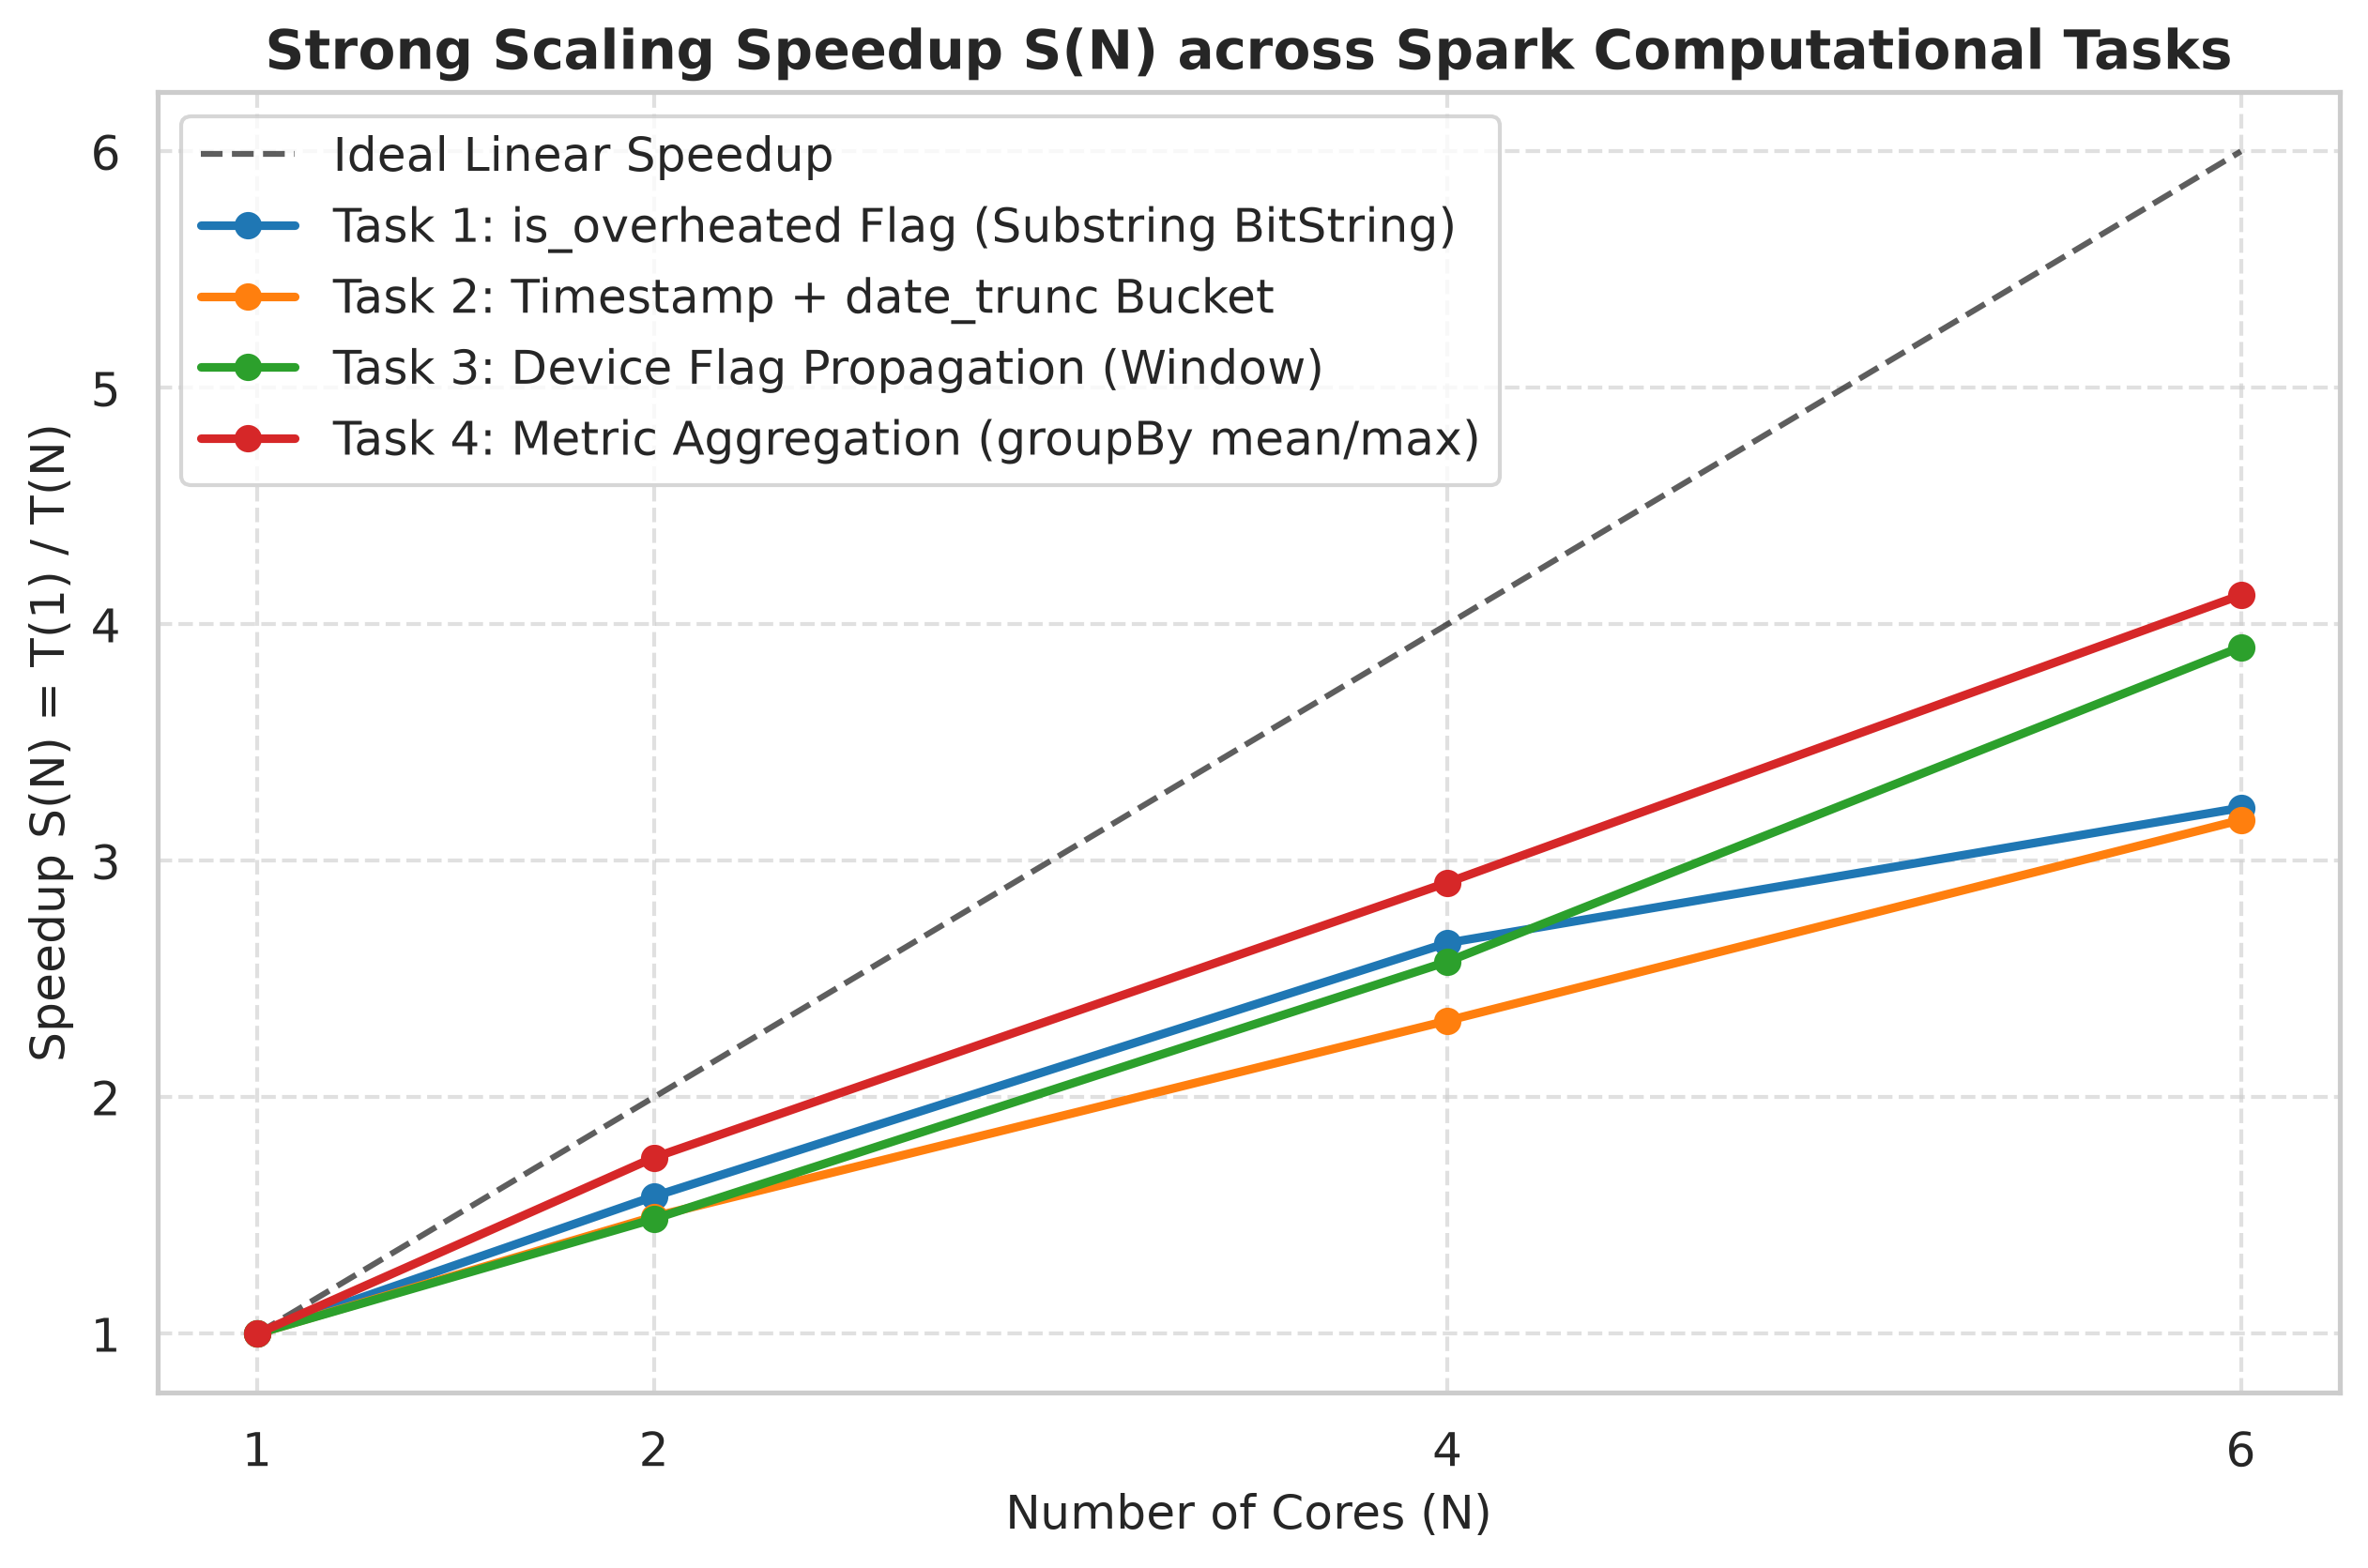

## 3. Parallel Efficiency E(N) = S(N) / N

**Figure 3** quantifies resource utilisation efficiency, defined as
E(N) = S(N) / N, where E(N) = 1 represents perfect linear scaling.

**Table 3 — Parallel Efficiency E(N)**

| Task | E(2) | E(4) | E(6) |
|---|---|---|---|
| Task 1: `is_overheated` flag | 79.0 % | 66.3 % | 53.7 % |
| Task 2: Timestamp + `date_trunc` | 74.8 % | 58.1 % | 52.9 % |
| Task 3: Device flag propagation | 74.3 % | 64.3 % | 65.1 % |
| Task 4: Metric aggregation | **87.2 %** | **72.7 %** | **68.7 %** |

Task 4 exhibits the highest efficiency at N = 2 (87.2 %), confirming that the
workload is sufficiently compute-bound that a second executor nearly halves
wall-clock time. Notably, Task 3 shows a slight *efficiency recovery* between
4 and 6 cores (64.3 % → 65.1 %), a little inflection attributable to the
hash-shuffle exchange becoming more load-balanced as partition count
grows with executor count.

Tasks 1 and 2 display the steepest efficiency decay. For Task 1, E(6) falls to
53.7 % because its absolute wall time (~0.35 s at 6 cores) is dominated by
Spark driver overhead; the per-record computation (substring extraction on
142 M rows) is exhausted before parallelism can be fully exploited. Task 2
mirrors this behaviour (E(6) = 52.9 %), with the additional penalty of
GC pressure from `timestamp_millis` intermediate object allocation, as
evidenced by GC time rising from 0.070 s at 1 core to 0.379 s at 6 cores.

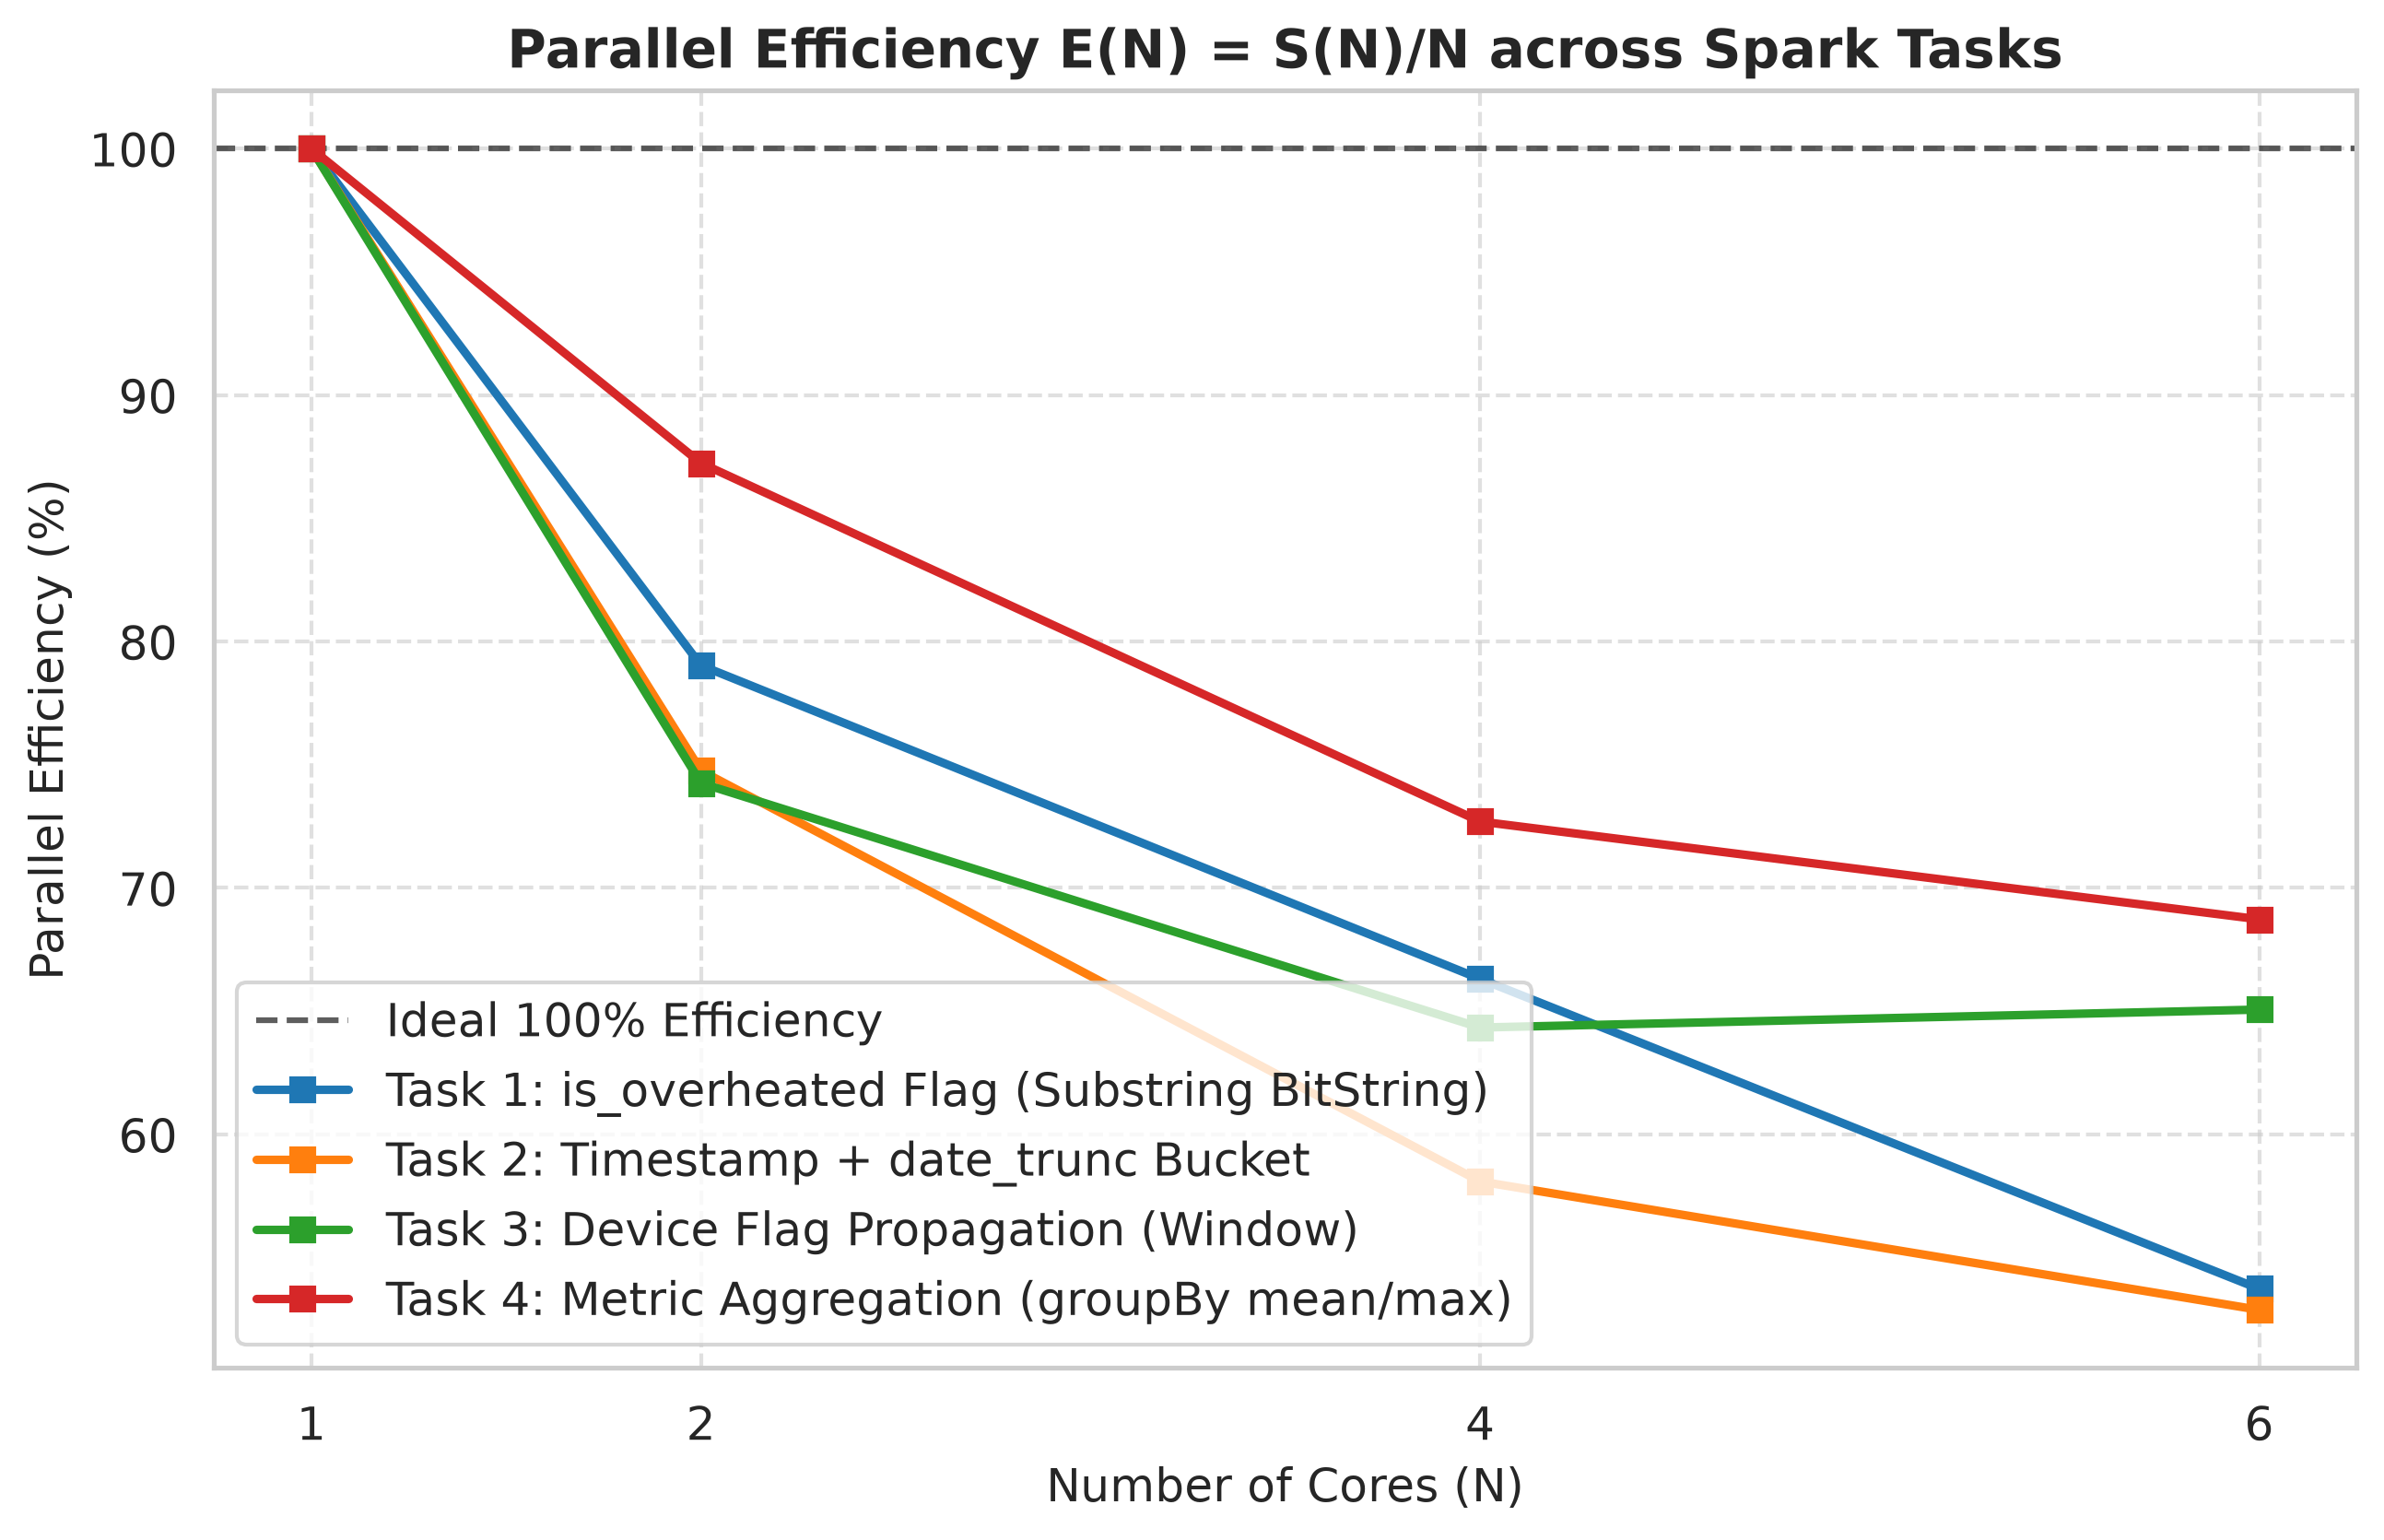

## 4. `spark.sql.shuffle.partitions` Sensitivity Analysis (Task 4, N = 6)

The pipeline operates with `spark.sql.shuffle.partitions = 200` as
default. To study the cost of under-partitioning, Task 4 — the only
shuffle-bound kernel — was re-executed at three sub-optimal cardinalities
(6, 12, 32) under identical hardware conditions (N = 6 cores, single timed run).

**Table 4 — Shuffle Partition Sensitivity (Task 4, N = 6 Cores)**

| `spark.sql.shuffle.partitions` | Wall-Clock Time (s) | CPU Time (s) | GC Time (s) | Tasks | Δ Wall vs. Default |
|---|---|---|---|---|---|
| 6 | 37.98 | 160.24 | 1.130 | 27 | +110.5 % |
| 12 | 36.45 | 157.03 | 1.158 | 39 | +102.0 % |
| 32 | 30.65 | 153.68 | 1.206 | 79 | +69.9 % |
| **200** *(default)* | **18.04** | **72.74** | **0.735** | **415** | — |

Three distinct effects are observable as partition count increases from 6 to 200:

**Wall-clock time.** Execution time decreases from 37.98 s at 6 partitions
to 18.04 s at 200 — a **2.10× reduction**. With only 6 partitions and 6 executors,
each executor is assigned a single post-shuffle partition on average; the reduce phase
therefore executes as a near-sequential single wave, leaving cores idle between
successive task assignments. At 200 partitions, 415 tasks are distributed
across executors continuously, eliminating idle time and fully exploiting available
parallelism.

**CPU time.** Total executor CPU time falls sharply from ~157–160 s at low partition
counts to 72.74 s at 200 partitions — a **2.18× reduction**. This counter-intuitive
improvement arises because finer partitions reduce the working-set size processed
by each task, enabling more efficient CPU cache utilisation during the hash-based
partial aggregation step. Fewer cache misses per task translate directly into lower
aggregate CPU cycles across the cluster.

**JVM GC overhead.** GC time decreases from 1.158 s at 12 partitions to 0.735 s at
200, as smaller per-task aggregation buffers impose lower peak heap pressure and allow
the JVM garbage collector to operate on shorter, less expensive collection cycles.

Collectively, these results demonstrate that `spark.sql.shuffle.partitions = 200` is
not merely a conservative upper bound but the configuration that simultaneously
maximises task parallelism, minimises CPU execution cost, and reduces GC pressure
for this workload. The 2.10× wall-time gain from correct partition sizing
even **exceeds the marginal gain of adding two executor cores (from 4 to 6)** (S gain ≈ 1.42×),
underscoring partition cardinality as the highest-leverage tuning parameter for
shuffle-bound stages on this cluster.

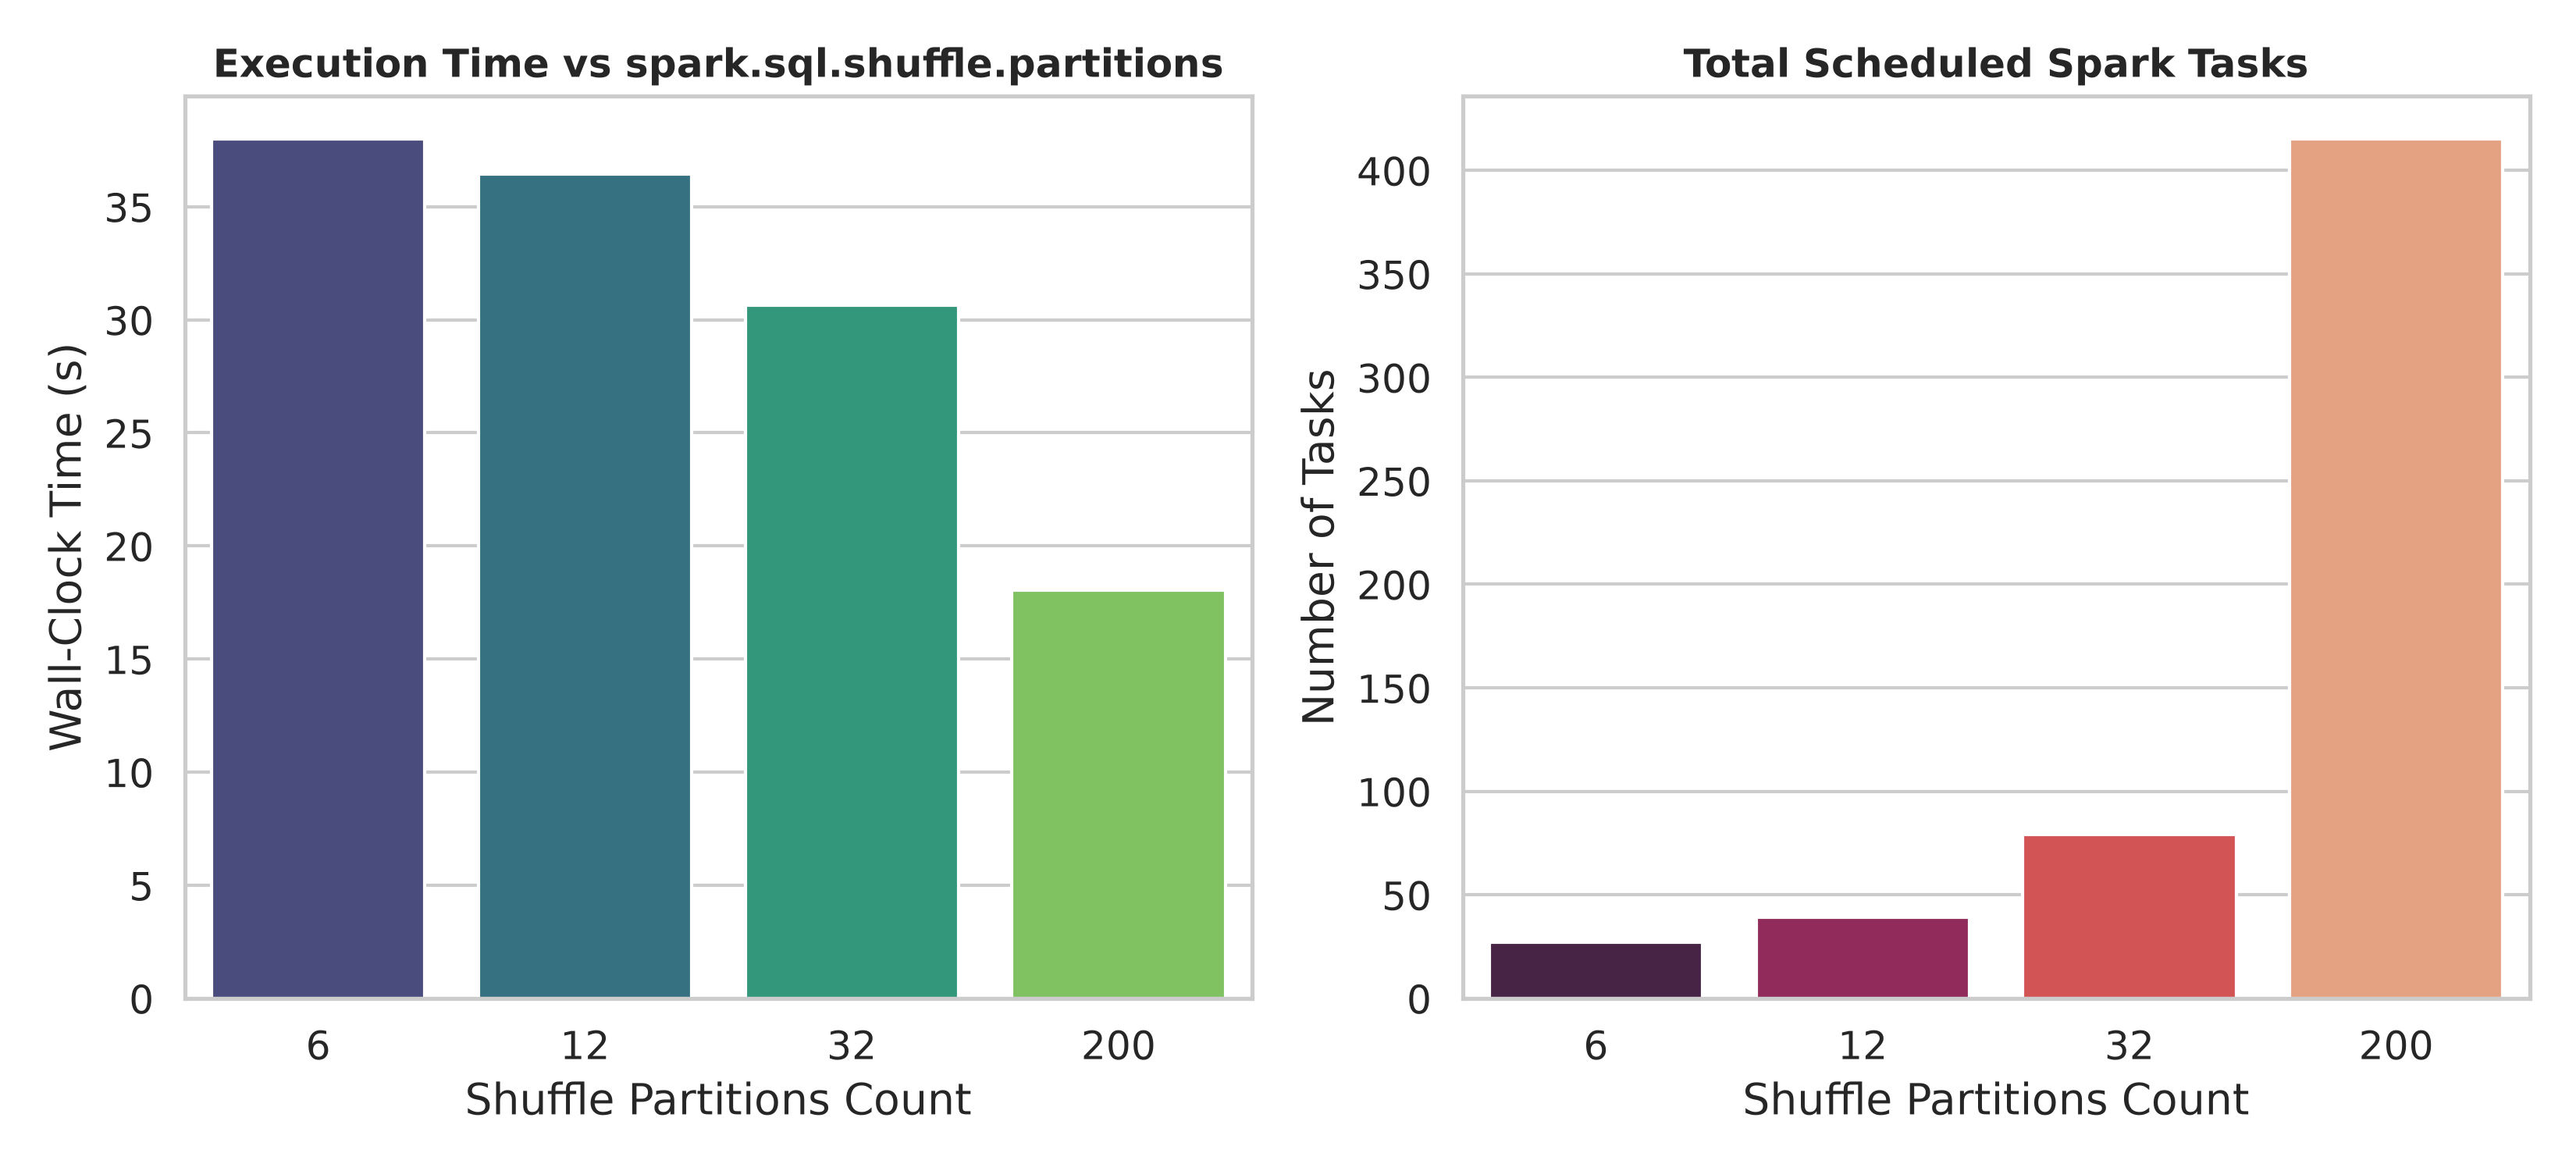


## 5. Execution-Time Breakdown at N = 6 Cores

**Figure 5** decomposes wall-clock time at maximum parallelism (N = 6) into three
components: (i) active CPU time normalised to a per-core equivalent (total executor
CPU time / N), (ii) JVM GC overhead, and (iii) residual network/I/O/shuffle-wait
time (wall time minus the sum of the preceding two).

At 6 cores, Tasks 1 and 2 contribute a combined **< 3.2 s** of wall time, and their
GC overhead is negligible (< 0.4 s). Task 3 accounts for ~20.5 s, of which
approximately 5.8 s (~28 %) is attributable to shuffle-wait.

Task 4 dominates at ~34.2 s. Decomposed:
- **Active CPU (per-core equivalent):** ≈ 24.9 s — the irreducible compute cost of
  the two-phase `coalesce(mean, max)` aggregation over 142 M input rows collapsing
  to 86.4 M output rows.
- **JVM GC overhead:** ≈ 1.01 s — driven by intermediate aggregation buffer
  allocation across 39 post-shuffle partitions.
- **Network / I/O / shuffle wait:** ≈ 8.3 s (≈ 24 % of wall time) — the cost
  of the hash-shuffle exchange between the map-side partial aggregate and the
  reduce-side final aggregate stages.

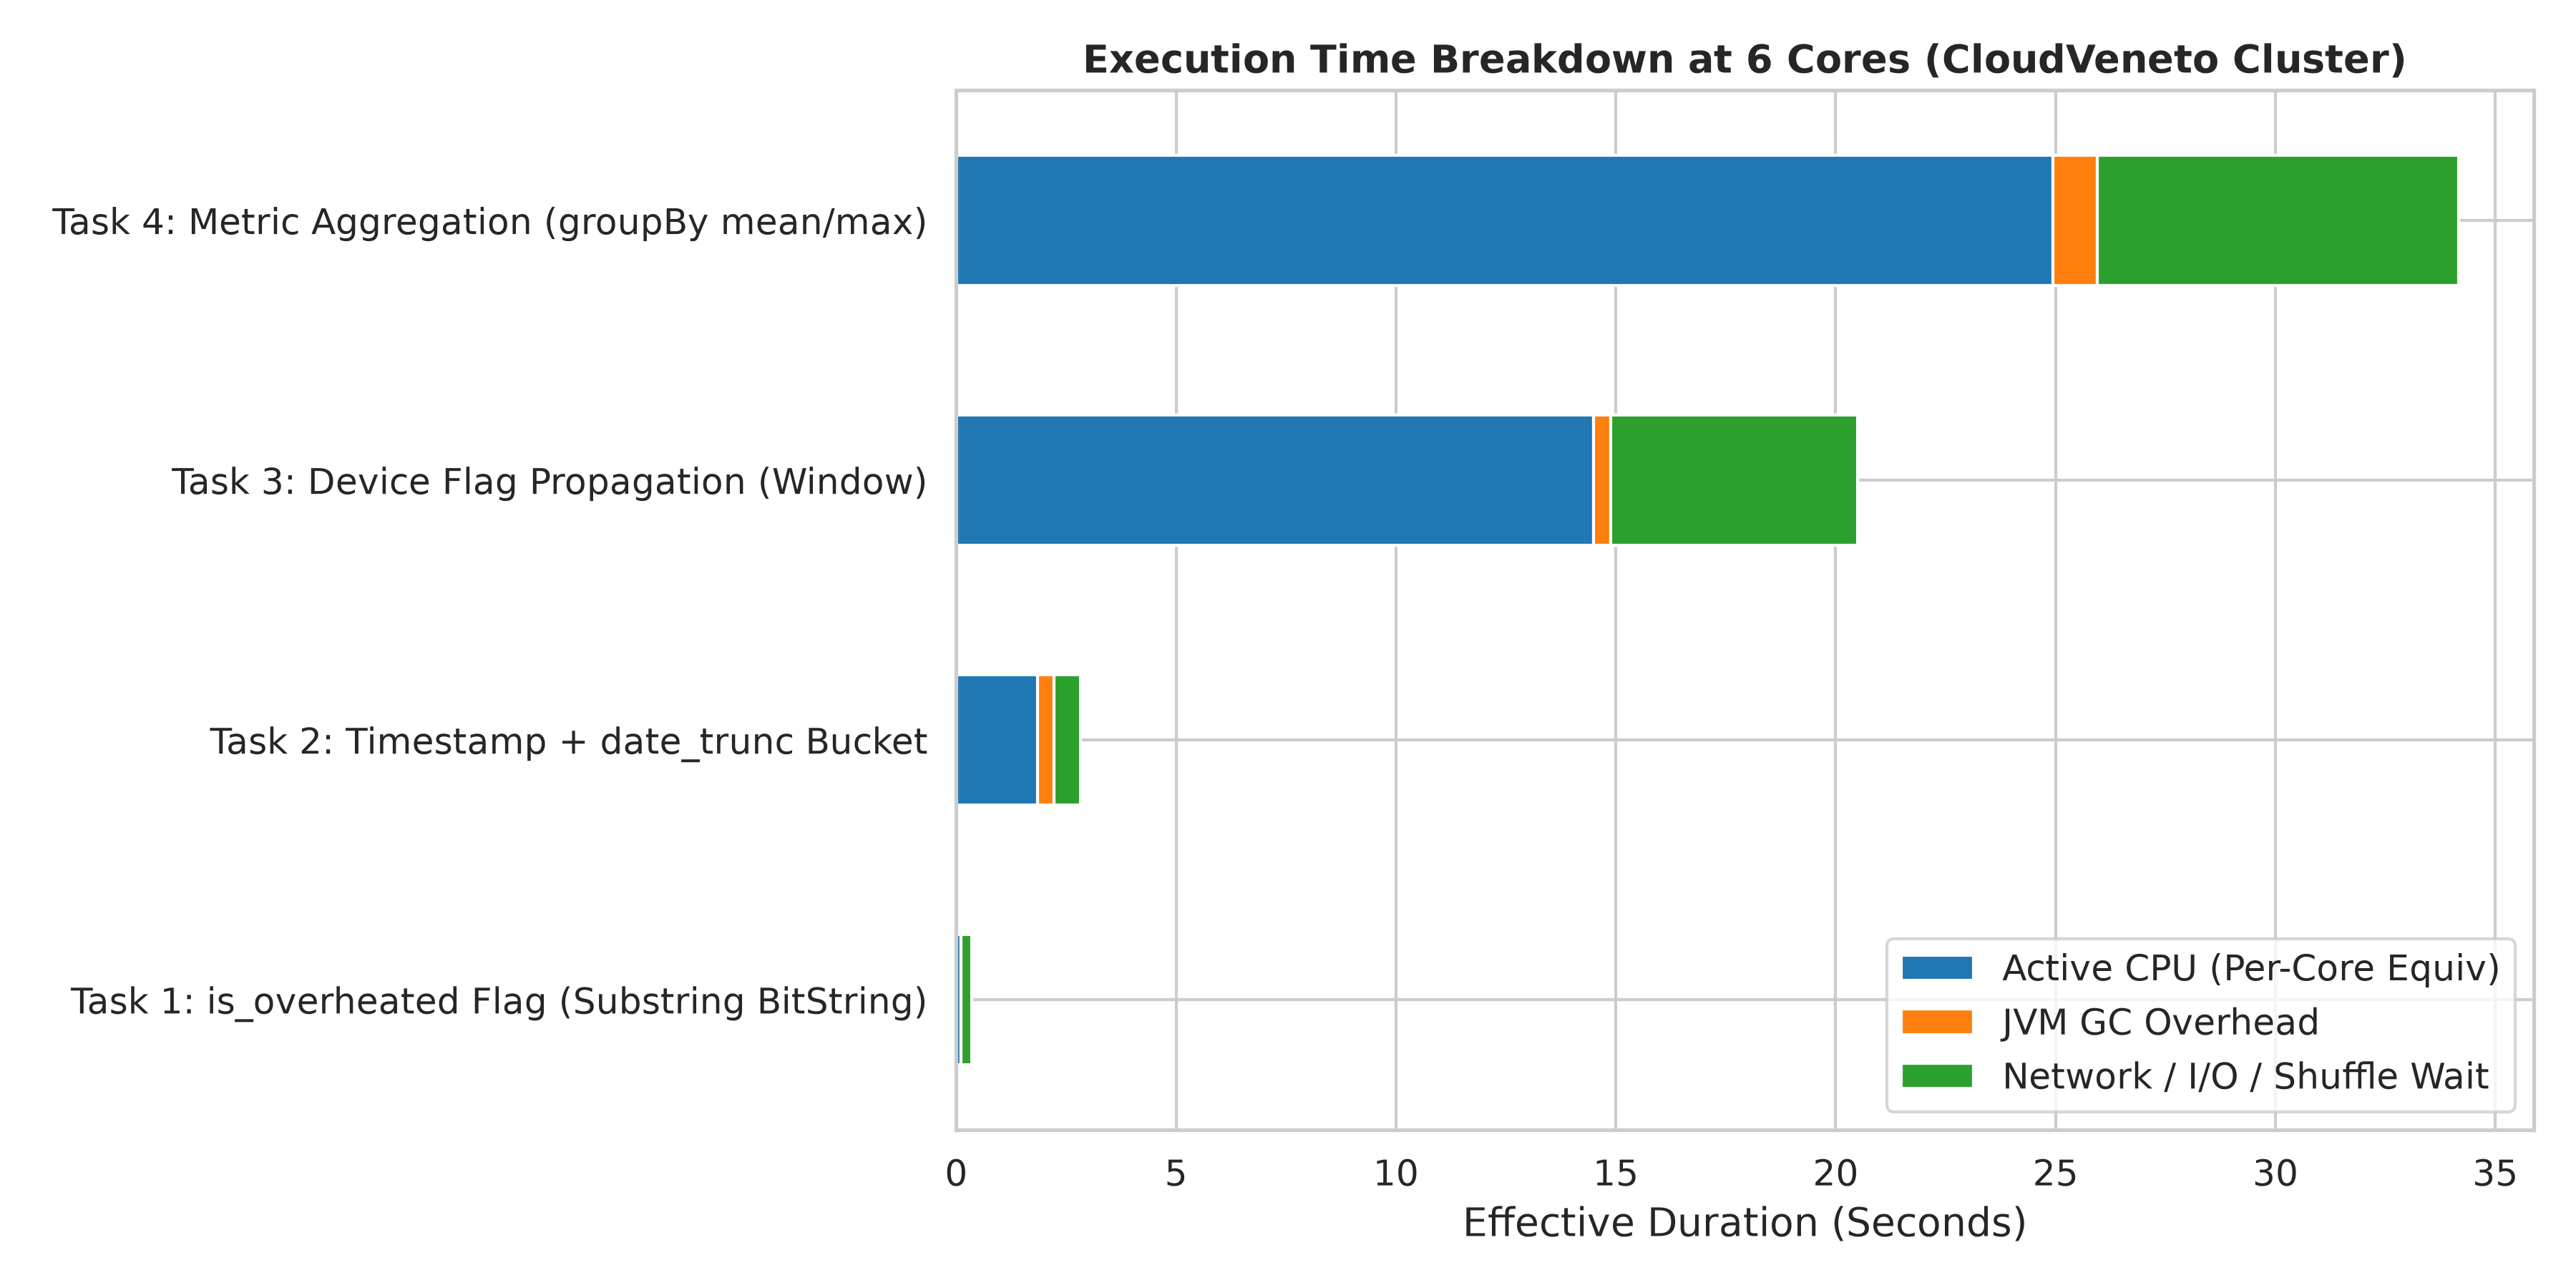

## 6. Synthesis and Operational Recommendations

The benchmark results establish two definitive conclusions for operating this pipeline
on a shared Spark cluster:

**1. Pipeline bottleneck profile: Wide-dependency dominance (Tasks 3 and 4).**
The latency is governed by the two wide-dependency transformations.
Task 3 and Task 4 jointly account for **95.6 %** of total wall-clock time at 1 core (220.87 s out of 230.94 s) and
**94.5 %** at 6 cores (54.65 s out of 57.82 s). The narrow map-side stages (Tasks 1 and 2)
execute in **< 3.2 s combined** at 6 cores (~5.5 % of total runtime). Given that
driver task-scheduling latency, RPC communication, and JVM serialisation constitute an
irreducible overhead floor for sub-second workloads, further optimisation of narrow tasks
yields negligible end-to-end gain. All performance engineering effort must target the
inter-executor shuffle exchanges introduced by Tasks 3 and 4.

**2. `spark.sql.shuffle.partitions = 200` is the required default; sub-optimal values
incur severe penalties.**
The pipeline is correctly configured with 200 post-shuffle partitions as its operational
default. Operating below this threshold imposes measurable regressions: at 12 partitions
Task 4 wall time rises to 36.45 s (+102.0 % over the 200-partition baseline of 18.04 s),
and at 6 partitions it reaches 37.98 s (+110.5 %). The root cause is coarse-grained task
allocation — at 12 partitions each executor holds only ~2 reduce-phase partitions on average,
leaving CPU cores idle between successive task waves and inflating GC overhead by 57 %
(1.158 s vs. 0.735 s). These penalties exceed the marginal benefit of scaling from 4 to
6 executor cores (Task 4 speedup gain: 1.42×), confirming that maintaining the correct
partition cardinality is a harder constraint than executor count for shuffle-bound workloads
on this cluster.
